# Car Market Trends Analysis with Car Dekho Data

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Loading the Dataset

In [4]:
df = pd.read_csv("Car Dekho Data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Understanding the Dataset

In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 301
Number of Columns: 9


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


## 4. Data Cleaning and Preprocessing

In [10]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 299


In [11]:
print("Fuel Types:")
print(df["Fuel_Type"].unique())
print("\nSeller Types:")
print(df["Seller_Type"].unique())
print("\nTransmission Types:")
print(df["Transmission"].unique())
print("\nOwners:")
print(df["Owner"].unique())

Fuel Types:
<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

Seller Types:
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str

Transmission Types:
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Owners:
[0 1 3]


In [12]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object

In [13]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Selling_Price"] = pd.to_numeric(df["Selling_Price"], errors="coerce")
df["Present_Price"] = pd.to_numeric(df["Present_Price"], errors="coerce")
df["Kms_Driven"] = pd.to_numeric(df["Kms_Driven"], errors="coerce")
df["Owner"] = pd.to_numeric(df["Owner"], errors="coerce")

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    str    
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    str    
 6   Seller_Type    299 non-null    str    
 7   Transmission   299 non-null    str    
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 23.4 KB


## 5. Feature Engineering

In [15]:
df["Car_Age"] = 2018 - df["Year"]
df[["Car_Name", "Year", "Car_Age"]].head()

,Car_Name,Year,Car_Age
0,ritz,2014,4
1,sx4,2013,5
2,ciaz,2017,1
3,wagon r,2011,7
4,swift,2014,4


In [16]:
df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]
df[["Car_Name", "Present_Price", "Selling_Price", "Depreciation"]].head()

,Car_Name,Present_Price,Selling_Price,Depreciation
0,ritz,5.59,3.35,2.24
1,sx4,9.54,4.75,4.79
2,ciaz,9.85,7.25,2.60
3,wagon r,4.15,2.85,1.30
4,swift,6.87,4.60,2.27


In [17]:
df["Resale_Percentage"] = (df["Selling_Price"] / df["Present_Price"]) * 100
df[["Car_Name", "Selling_Price", "Present_Price", "Resale_Percentage"]].head()

,Car_Name,Selling_Price,Present_Price,Resale_Percentage
0,ritz,3.35,5.59,59.928444
1,sx4,4.75,9.54,49.790356
2,ciaz,7.25,9.85,73.604061
3,wagon r,2.85,4.15,68.674699
4,swift,4.60,6.87,66.957787


In [18]:
print("Average Selling Price:",round(df["Selling_Price"].mean(), 2), "Lakh")

Average Selling Price: 4.59 Lakh


In [19]:
print("Average Present Price:",round(df["Present_Price"].mean(), 2), "Lakh")

Average Present Price: 7.54 Lakh


In [20]:
print("Average KMs Driven:",round(df["Kms_Driven"].mean()), "KM")

Average KMs Driven: 36917 KM


In [21]:
print("Average Vehicle Age:",round(df["Car_Age"].mean(), 2), "Years")

Average Vehicle Age: 4.38 Years


## 6. Exploratory Data Analysis

### 6.1 Selling Price Distribution

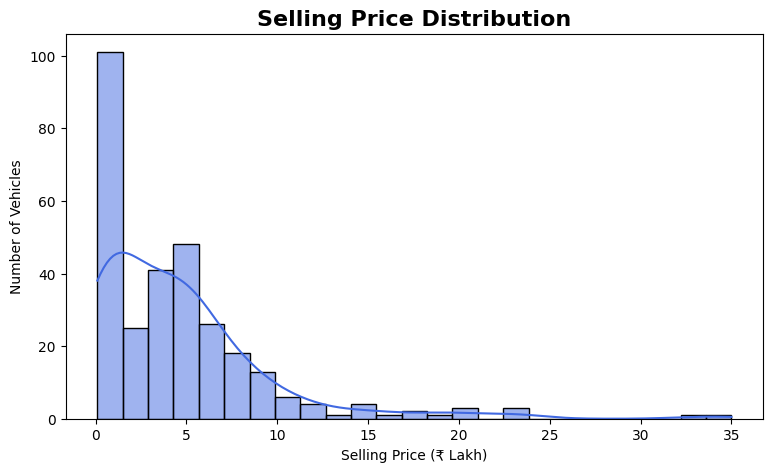

In [29]:
plt.figure(figsize=(9, 5))
sns.histplot(
    df["Selling_Price"],
    bins=25,
    kde=True,
    color="royalblue"
)
plt.title("Selling Price Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Selling Price (₹ Lakh)")
plt.ylabel("Number of Vehicles")
plt.show()

### 6.2 Car Age vs Selling Price

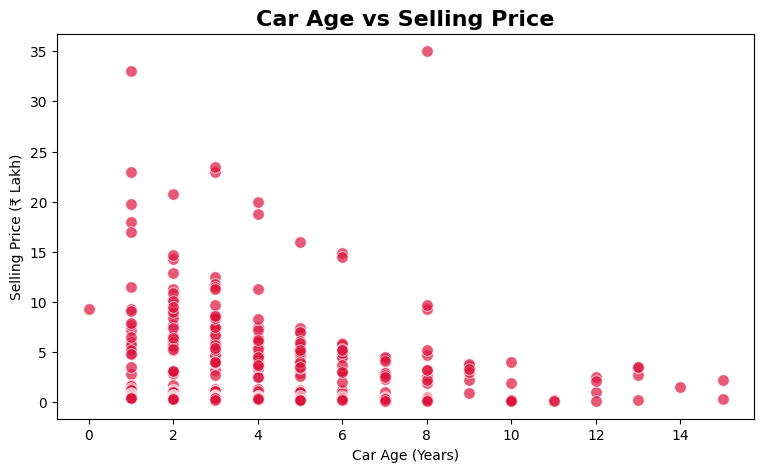

In [30]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price",
    color="crimson",
    s=70,
    alpha=0.7
)
plt.title("Car Age vs Selling Price", fontsize=16, fontweight="bold")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (₹ Lakh)")
plt.show()

### 6.3 KMs Driven vs Selling Price

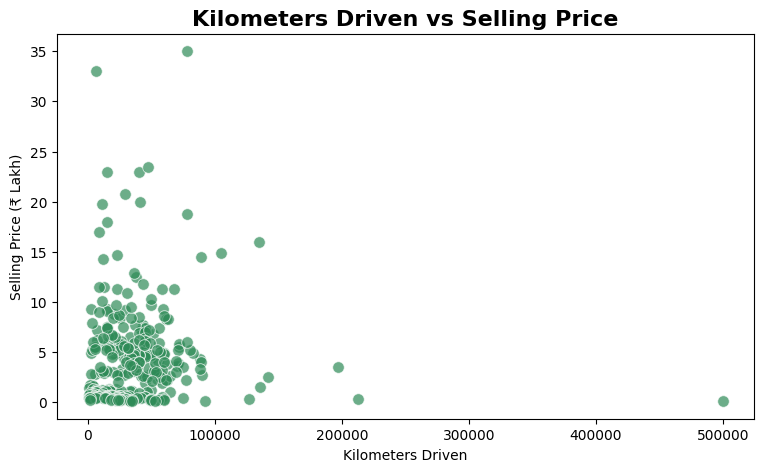

In [31]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price",
    color="seagreen",
    s=70,
    alpha=0.7
)
plt.title("Kilometers Driven vs Selling Price", fontsize=16, fontweight="bold")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (₹ Lakh)")
plt.show()

### 6.4 Average Selling Price by Fuel Type

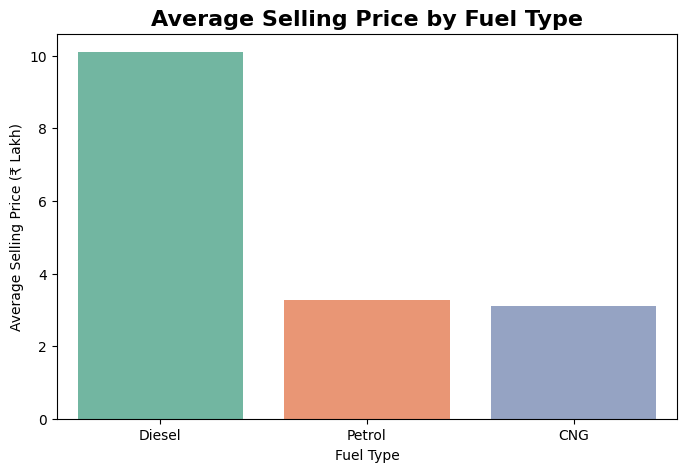

In [32]:
fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=fuel_price.index,
    y=fuel_price.values,
    hue=fuel_price.index,
    palette="Set2",
    legend=False
)
plt.title("Average Selling Price by Fuel Type", fontsize=16, fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price (₹ Lakh)")
plt.show()

### 6.5 Correlation Heatmap

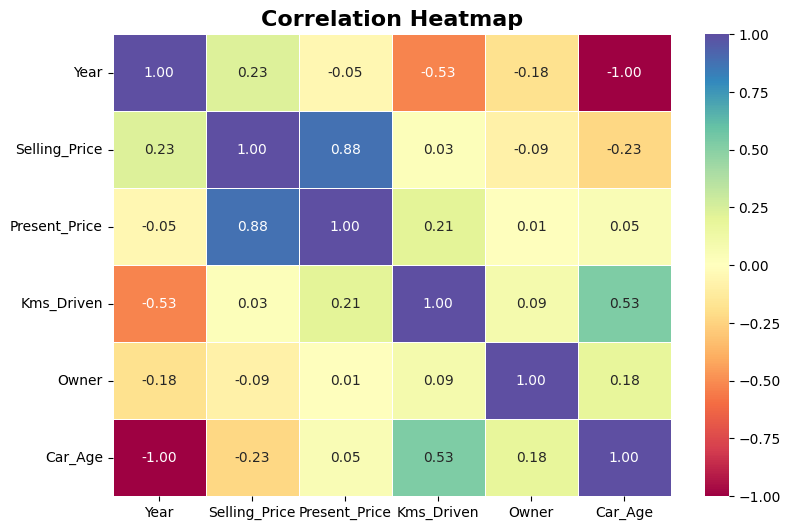

In [33]:
correlation = df[
    ["Year", "Selling_Price", "Present_Price",
     "Kms_Driven", "Owner", "Car_Age"]
].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.show()

## 7. Conclusion & Key Takeaways

### 🔹 Primary Value Driver
**Present_Price** is the strongest factor influencing **Selling_Price**, with a very high positive correlation of **0.88**.
### 🔹 Depreciation & Age
Vehicle resale value decreases as age increases, with a correlation of **-0.23**. The average vehicle age is **4.38 years**, and vehicles retain approximately **60.8%** of their original price.
### 🔹 Fuel Type
**Diesel vehicles** have the highest average resale value among the fuel types in the dataset.
### 🔹 Mileage
**Kms_Driven** has a relatively weak direct correlation with **Selling_Price (0.03)**, while **Car_Age** and **Kms_Driven** have a moderate correlation of **0.53**.
### 🔹 Ownership
The number of previous owners has a slight negative relationship with resale price, with a correlation of **-0.09**.

### 💡 Overall Conclusion
The analysis shows that **original showroom price is the strongest indicator of resale value**, while **vehicle age is an important factor in depreciation**. Selling a vehicle within approximately **4–5 years** can provide a good balance between usage and residual value.